# 18_01 — Simulación y preprocesamiento · **Escenario B: FAR con signo conmutado**

Paso **1 de 3** del ciclo `Python → MATLAB → Python`:

| Paso | Archivo | Qué hace |
|---|---|---|
| 1 | **este notebook** | genera los datos, ajusta base + FPCA + estandarizador, escribe los datasets AR y todos los artefactos |
| 2 | `psbp_fd_iteracion.m` | muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento |
| 3 | `18_03_convergencia` / `18_04_evaluacion` / `18_05_comparacion` | diagnóstico de cadenas, evaluación fuera de muestra y modelos de referencia |

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de
experimento. Todo lo demás se deriva de ellas.

---

## Qué es el Escenario B y por qué existe

**No es un Algoritmo del anexo**, igual que el Escenario A de la corrida 17: se
nombra con letra para que no colisione con los ids 1–6. El generador es

$$X_t(\tau) \;=\; \mu(\tau) \;+\; s_t \int_0^1 \psi(\tau,u)\,\bigl(X_{t-1}(u)-\mu(u)\bigr)\,du \;+\; \varepsilon_t(\tau),$$

$$\mathbb{P}(s_t = +1 \mid X_{t-1}) \;=\; \Phi\bigl(\kappa\,(z_{t-1} - c)\bigr), \qquad z_{t-1} = \langle X_{t-1}-\mu,\; e\rangle_{L^2},$$

es decir el **FAR(1) del Algoritmo 1 con el signo del operador conmutado por un
umbral sobre el estado rezagado**. Los dos regímenes son $\Psi$ y $-\Psi$:
**antisimétricos**.

### El problema que viene a resolver

El cuello de botella del capítulo no es que falten escenarios que rompan un
supuesto, sino que **los que existen rompen supuestos que la clase lineal
tampoco necesita**:

| Escenario | Media condicional | ¿Discrimina el MISE? |
|---|---|---|
| 1 | lineal en $X_{t-1}$ | no: el FAR(1) está **correctamente especificado** |
| 2 | **constante** | no: la media incondicional es la predicción óptima |
| 4 | la del 1 | no: sólo cambia la ley de la innovación |
| 21 (real) | RESET no rechaza linealidad | no |

En los cuatro casos el PSBPM-FD queda igual o levemente peor que un FAR(1), y
**no por defecto del modelo**: no hay nada que ganar en la media condicional.

Este escenario construye el caso contrario **por simetría**. El mejor predictor
lineal depende del proceso sólo a través de la covarianza cruzada

$$C_1 \;=\; \mathbb{E}\bigl[Y_t \otimes Y_{t-1}\bigr] \;=\; \Psi\;\mathbb{E}\bigl[s(Y_{t-1})\, Y_{t-1}\otimes Y_{t-1}\bigr],$$

cuyo integrando es **par** en $Y$ multiplicado por un signo **impar**: si la ley
de $Y$ fuera exactamente simétrica, $C_1$ sería el operador **nulo** y el mejor
predictor lineal sería la media incondicional. La cancelación es casi completa
cuando la dirección de conmutación $e$ es ortogonal a la dirección dominante
del proceso, que es exactamente lo que se elige aquí ($e \propto \sin 2\pi\tau$,
$\gamma = 0.60$).

Resultado, medido en §2.3 sobre esta misma corrida:

| Cantidad | Valor |
|---|---|
| $R^2$ del **mejor predictor lineal** (fuera de muestra) | $\approx 0$ |
| $R^2$ de la **media condicional verdadera** (oráculo) | $\approx 0.38$ |
| autocorrelación puntual a rezago 1 | $\approx 0.05$ |

o sea: **la serie parece ruido blanco a cualquier diagnóstico lineal y sin
embargo un tercio largo de su varianza es predecible**. El FAR(1), el VAR sobre
scores y toda la clase lineal homogénea quedan clavados en la media
incondicional. Eso es lo que este notebook llama *que el FAR muera*.

### Qué lo distingue del Escenario 3

El Algoritmo 3 también conmuta el operador según el estado rezagado. Difiere en
dos puntos, y **ambos son la corrección de lo que falló en la corrida 13**:

1. Los regímenes son **antisimétricos** ($\Psi$, $-\Psi$) y no dos operadores de
   distinta persistencia. La separación entre las dos medias condicionales es
   $2\lVert\Psi Y_{t-1}\rVert$: **proporcional al estado**, no una constante.
2. Por eso **no hay desplazamientos de nivel**. El desplazamiento del Algoritmo 3
   es de rango uno sobre la dirección constante y se lleva el 94 % de la
   varianza, de modo que subirlo para separar las modas empuja la regla del 95 %
   hacia $M=1$ y deja al escenario sin eje de interpretabilidad. Aquí la
   separación la produce la dinámica y el espectro no se degrada.

Y hay algo que ningún otro escenario tiene: **la dirección de conmutación no es
la primera componente principal, es esencialmente la segunda**. Con $M=1$ el
modelo **no observa** la covariable que gobierna la conmutación y no puede sino
fallar como el FAR; con $M\geq 2$ sí la observa. El barrido en $M$ pasa así de
medir una degradación suave a tener **un punto de corte predicho de antemano**.

### Qué hay que mirar al leer los resultados

| Afirmación | Dónde se verifica | Criterio |
|---|---|---|
| el mejor lineal no supera a la media incondicional | `_01 §2.3` y `_05 §4` | $R^2_{\text{lineal}} \approx 0$ |
| hay señal que recuperar | `_01 §2.3` | $R^2_{\text{oráculo}} \gg 0$ |
| la conmutación entra en el modelo recién con $M\ge2$ | `_01 §3.4`, `_04 §11` | $\lvert\langle e,\phi_2\rangle\rvert$ grande |
| el PSBPM-FD aprovecha la brecha | `_05 §7` | MISE test **por debajo** del VAR/FAR1 |
| la predictiva es bimodal donde debe | `_04 §9.1` | Sarle en orígenes ambiguos vs deterministas, **contra el oráculo** |

La última fila es la que la corrida 13 no pudo cerrar por falta de referencia
*oracle*: aquí el coeficiente de Sarle de la ley condicional **verdadera** se
calcula de forma exacta en `resumen_escenario_B` y viaja en los artefactos.


## 1. Imports y rutas

In [63]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenarioB, generar_escenario_B, guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
from model_psbp_fd.utils import get_project_root
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento

`ESCENARIO_ID` es una **cadena** (`"B"`), no un entero: el `psbp_fd_iteracion.m`
de esta carpeta usa `%s` en su `sprintf` por ese motivo, igual que el de la
corrida 17.

`M_FPCA` vive aquí y no en §3.4 porque forma parte del `EXPERIMENT_ID`, y las
cinco rutas del contrato se construyen en la celda siguiente — antes de que
exista el objeto FPCA. La convención del identificador es

    <basename>_<escenario>_r<réplica a 2 dígitos>_m<M a 2 dígitos>

de modo que cada punto del barrido en `M` escribe sus propios datos, trazas y
reportes, y ninguno pisa a los demás.

In [64]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario"
ESCENARIO_ID = "B"    # escenario de diagnóstico; NO es un Algoritmo del anexo
REPLICA_ID   = 3      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

# ── [BARRIDO] Componentes FPCA retenidas ─────────────────────────────────
# M entra DOS VECES en el modelo: como número de mezclas y como dimensión
# p = q·M del predictor de los pesos probit. Por eso es un eje del estudio y no
# un detalle de preprocesamiento, y por eso viaja en el EXPERIMENT_ID: cada
# valor de M escribe sus propios artefactos y no pisa los de los demás.
#
# La regla declarada es la primera M con varianza acumulada ≥ 95 %; los valores
# por encima y por debajo se corren para medir la sensibilidad. §3.4 contrasta
# este valor con el que da la regla y verifica que no exceda el K disponible.
#
# Al cambiarlo hay que cambiarlo TAMBIÉN en 18_03, 18_04, 18_05 y en
# psbp_fd_iteracion.m: los cinco arman el mismo EXPERIMENT_ID a mano.

# Usaremos (1, 2, 3). El punto M=1 es el que la portada predice que debe
# fallar: con una sola componente el modelo no observa la dirección de
# conmutación, que carga sobre la SEGUNDA. No es un punto de relleno del
# barrido, es la mitad del experimento.
M_FPCA = 1

EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}_m{M_FPCA:02d}"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · M {M_FPCA} · seed base {SEED}")

PROJECT_ROOT  : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_ID : escenario_B_r03_m01
Escenario B · réplica 3 · M 1 · seed base 41232


In [65]:
# Las cinco rutas del contrato. No existe un config_paths en Python: cada
# notebook lo arma aquí y config_paths.m replica las mismas del lado MATLAB.
PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for nombre, ruta in PATHS.items():
    ruta.mkdir(parents=True, exist_ok=True)
    print(f"  {nombre:12s} → {ruta}")

  raw          → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_B_r03_m01
  functional   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_B_r03_m01
  predict      → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_B_r03_m01
  out_report   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_B_r03_m01
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_B_r03_m01


## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

Los parámetros del esquema de observación son los **fijos del estudio** y son
idénticos a los de la corrida 20, para que la comparación 20 ↔ 18 aísle el
mecanismo y no mezcle diseños de observación.

Lo que cambia respecto del Algoritmo 1 son tres cosas, y cada una tiene un
motivo cuantitativo:

- **`gamma = 0.60`** (el Algoritmo 1 usa 0.30). Cuanto más ancho es el núcleo,
  más se concentra el rango de $\Psi$ sobre la dirección casi constante y más
  ortogonal queda a la dirección de conmutación — que es la condición bajo la
  cual la covarianza cruzada se cancela. Medido en una corrida larga con el
  resto fijo: $R^2$ del mejor lineal **0.031 con `gamma=0.30`** contra **0.002
  con `gamma=0.60`**, mientras el del oráculo sube de 0.327 a 0.341.
- **`hs_norm = 0.90`** (el Algoritmo 1 usa 0.70). La media condicional es
  $s_t\Psi Y_{t-1}$: su varianza crece con `hs_norm` y con ella el $R^2$ del
  oráculo. Se sube a propósito para que la brecha sea inequívoca y no haya que
  discutirla contra el ruido Monte Carlo con $R=1$. **Al comparar con la
  corrida 20 hay que declarar que la persistencia difiere.**
- **`nitidez = 4.0`**. Es la pendiente del probit en unidades de $z$; lo
  interpretable es `nitidez_en_sd_z` $\approx 1.5$. Deja ~35 % de orígenes
  **ambiguos** ($p\in[0.25,0.75]$) — la corrida 13 tenía 14 % — conservando la
  brecha oráculo/lineal. Subirla la agranda **y elimina los orígenes
  bimodales**, que son los únicos con contenido para el eje distribucional: es
  exactamente el intercambio que el escenario pone sobre la mesa.

`ell = 0.5` y `sigma_eps = 1.0` son los del anexo. El umbral es 0 porque con la
dirección oscilatoria $z$ tiene media prácticamente nula; §2.3 verifica la
proporción efectiva de cada signo.


In [66]:
# -- Parámetros fijos del estudio (comunes a todas las corridas) -------------
L_GRILLA   = 75     # puntos de la grilla regular tau_1=0 ... tau_L=1
T_CURVAS   = 400    # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento  -> T0 = 280
SIGMA_OBS  = 0.25   # desviación del ruido de medición

def media_senoidal(tau):
    """mu(tau) = sin(2 pi tau). La media vigente del estudio (tab:ane_esquema)."""
    return np.sin(2.0 * np.pi * tau)

SIM_CFG = ConfigEscenarioB(
    # Esquema de observación - idéntico a la corrida 20
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 200,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_senoidal,
    # Operador autorregresivo - gamma y hs_norm difieren del Algoritmo 1 (ver 2.1)
    gamma     = 0.60,
    hs_norm   = 0.90,
    # Innovación funcional - idéntica al anexo
    sigma_eps = 1.0,
    ell       = 0.5,
    # Conmutación del signo
    nitidez   = 4.0,
    umbral    = 0.0,
    signos    = (1.0, -1.0),   # antisimétrico: Psi y -Psi
    # direccion_fn = None  =>  direccion_oscilatoria: e(tau) proporcional a sin(2 pi tau)
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<18}: {v}")

# La antisimetría no es un detalle de parametrización: es lo que hace que la
# covarianza cruzada se cancele. Con signos de distinta magnitud (p. ej.
# (1.0, 0.2)) el escenario sigue siendo no lineal pero el FAR(1) recupera buena
# parte de la señal, y deja de cumplir su propósito.
assert np.isclose(SIM_CFG.signos[0], -SIM_CFG.signos[1]), \
    "El escenario pierde su razón de ser si los dos signos no son opuestos."


  L                 : 75
  T                 : 400
  burn_in           : 200
  sigma_obs         : 0.25
  R                 : 1
  seed              : 41232
  media_fn          : media_senoidal
  jitter            : 1e-10
  gamma             : 0.6
  hs_norm           : 0.9
  sigma_eps         : 1.0
  ell               : 0.5
  nitidez           : 4.0
  umbral            : 0.0
  signos            : (1.0, -1.0)
  direccion_fn      : None
  n_dim_diagnostico : 5


### 2.2 Generación

In [67]:
salida = generar_escenario_B(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA - alimenta la estimación
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA - objetivo de evaluación
grilla = salida.grilla
T, G   = X_raw.shape

DIAG = salida.diagnostico

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in DIAG.items():
    print(f"  {k:36s} = {v}")


IndexError: index 2 is out of bounds for axis 0 with size 1

### 2.3 Verificación del mecanismo — **la celda que decide si el escenario sirve**

Análogo a la reconstrucción de $p_t$ de la corrida 13 y del residuo AR de la 14:
antes de seguir, se comprueba que el generador hace lo que se le pidió. Aquí la
verificación no es un detalle de higiene sino **el resultado central del
escenario**, y por eso va antes que cualquier ajuste.

`resumen_escenario_B` proyecta el proceso sobre sus primeras componentes
principales empíricas, ajusta el **mejor predictor lineal** por mínimos
cuadrados sobre la primera mitad de la serie, lo evalúa en la segunda, y lo
compara con el $R^2$ que alcanza la **media condicional verdadera** en el mismo
tramo. La partición evita que el $R^2$ del lineal quede inflado por
sobreajuste — que es justamente el sesgo que haría parecer favorable al
escenario sin serlo.

Los tres `assert` son las tres condiciones que el escenario debe cumplir:

1. **el lineal no gana nada**, `r2_lineal_fuera_de_muestra < 0.05`;
2. **hay algo que ganar**, `r2_oraculo_fuera_de_muestra > 0.15`;
3. **hay orígenes con dos modas**, `fraccion_origenes_ambiguos > 0.15`.

Si alguno falla, el escenario no discrimina y no tiene sentido gastar MCMC en
él. `separacion_modas_en_sd_innovacion` y el coeficiente de Sarle **exacto** de
la ley condicional verdadera completan el cuadro: son la referencia *oracle*
que a la corrida 13 le faltó, y sin la cual un Sarle bajo en la predictiva del
modelo no distingue un fallo del modelo de un generador sin contenido.


In [ ]:
# -- 1. El mejor predictor lineal no supera a la media incondicional --------
R2_LIN = DIAG["r2_lineal_fuera_de_muestra"]
R2_ORC = DIAG["r2_oraculo_fuera_de_muestra"]

print(f"R2 del mejor predictor LINEAL (fuera de muestra) : {R2_LIN:+.4f}")
print(f"R2 del mejor predictor LINEAL (dentro de muestra): "
      f"{DIAG['r2_lineal_dentro_de_muestra']:+.4f}   <- inflado por sobreajuste")
print(f"R2 de la media condicional VERDADERA (oráculo)   : {R2_ORC:+.4f}")
print(f"brecha oráculo - lineal                          : "
      f"{DIAG['brecha_oraculo_lineal']:+.4f}")
print(f"acf1 puntual de la serie generada                : {DIAG['acf1_media']:+.4f}"
      "   <- la serie 'parece' ruido blanco")

assert R2_LIN < 0.05, (
    f"El mejor predictor lineal alcanza R2={R2_LIN:.3f}: el FAR(1) NO muere en "
    "este escenario y no cumple su propósito. Revisar gamma (más ancho => más "
    "cancelación) y la dirección de conmutación (debe ser casi ortogonal a la "
    "primera componente).")
assert R2_ORC > 0.15, (
    f"El oráculo sólo alcanza R2={R2_ORC:.3f}: no hay señal que recuperar y el "
    "escenario no distingue un modelo flexible de uno lineal. Subir hs_norm o "
    "nitidez.")

# -- 2. La conmutación: proporciones, rachas y ambigüedad -------------------
print(f"\nproporción de signo +1         : {DIAG['proporcion_signo_positivo']:.3f}"
      "   (0.5 => umbral bien centrado)")
print(f"duración media de racha        : {DIAG['duracion_media_racha']:.2f} períodos")
print(f"sd del estado z                : {DIAG['sd_proyeccion_estado']:.4f}")
print(f"nitidez en unidades de sd(z)   : {DIAG['nitidez_en_sd_z']:.2f}")
print(f"orígenes ambiguos (p en .25-.75): {DIAG['fraccion_origenes_ambiguos']:.1%}"
      f"  ({DIAG['n_origenes_ambiguos']} de {T})")

assert DIAG["fraccion_origenes_ambiguos"] > 0.15, (
    "Menos del 15 % de los orígenes son ambiguos: la conmutación es casi "
    "determinista y no quedan orígenes con dos modas, que son los únicos con "
    "contenido para el eje distribucional. Bajar `nitidez`.")

# -- 3. Bimodalidad de la ley condicional VERDADERA (referencia oracle) -----
print(f"\nseparación entre modas         : "
      f"{DIAG['separacion_modas_en_sd_innovacion']:.2f} sd de la innovación")
print(f"|arrastre| / sd innovación (u1) : {DIAG['razon_arrastre_innovacion_u1']:.2f}"
      "   (>1 => las dos modas se separan sobre la 1a FPC)")
print(f"orígenes genuinamente bimodales : {DIAG['fraccion_origenes_bimodales']:.1%}"
      "   (ambiguos Y con estado grande)")
print("\ncoeficiente de Sarle EXACTO de la ley condicional verdadera:")
print(f"  orígenes bimodales   : {DIAG['sarle_oraculo_bimodales']:.4f}")
print(f"  orígenes ambiguos    : {DIAG['sarle_oraculo_ambiguos']:.4f}")
print(f"  orígenes determinist.: {DIAG['sarle_oraculo_deterministas']:.4f}")
print(f"  referencias          : uniforme {DIAG['sarle_referencia_uniforme']:.4f}"
      f" · gaussiana {DIAG['sarle_referencia_gaussiana']:.4f}")
print("\nEstas tres cifras son el TECHO contra el que 18_04 §9.1 contrasta el "
      "mismo coeficiente\ncalculado sobre la predictiva del modelo. La corrida 13 "
      "no las tenía y por eso no\npudo decidir si su Sarle bajo era hallazgo o "
      "defecto de diseño.")

print("\n[OK] mecanismo verificado: el lineal muere y el oráculo no")


R2 del mejor predictor LINEAL (fuera de muestra) : -0.0377
R2 del mejor predictor LINEAL (dentro de muestra): +0.0074   <- inflado por sobreajuste
R2 de la media condicional VERDADERA (oráculo)   : +0.3761
brecha oráculo - lineal                          : +0.4138
acf1 puntual de la serie generada                : +0.0493   <- la serie 'parece' ruido blanco

proporción de signo +1         : 0.512   (0.5 => umbral bien centrado)
duración media de racha        : 2.16 períodos
sd del estado z                : 0.3803
nitidez en unidades de sd(z)   : 1.52
orígenes ambiguos (p en .25-.75): 35.2%  (141 de 400)

separación entre modas         : 2.29 sd de la innovación
|arrastre| / sd innovación (u1) : 1.30   (>1 => las dos modas se separan sobre la 1a FPC)
orígenes genuinamente bimodales : 18.8%   (ambiguos Y con estado grande)

coeficiente de Sarle EXACTO de la ley condicional verdadera:
  orígenes bimodales   : 0.5807
  orígenes ambiguos    : 0.4726
  orígenes determinist.: 0.3858
  referen

In [ ]:
# Configuración de simulación + escenario completo en .npz
simulation_config = {
    "sim_params":    salida.config.to_dict(),
    "diagnostico":   DIAG,
    "replica_idx":   REPLICA_IDX,
    "experiment_id": EXPERIMENT_ID,
    "escenario_id":  ESCENARIO_ID,     # cadena "B", no entero; el .m usa %s
    "replica_id":    int(REPLICA_ID),
    "seed":          SEED,
    "T": int(T), "G": int(G),
}
with open(PATHS["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
    json.dump(simulation_config, f, indent=2, ensure_ascii=False)

_npz = guardar_escenario(salida, str(PATHS["raw"] / f"escenario_{ESCENARIO_ID}"),
                         incluir_curvas=True, incluir_internos=True)
print(f"[raw] simulation_config.json  ·  {_npz}")

[raw] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_B_r01_m01\escenario_B.npz


### 2.4 Persistencia del estado verdadero

El **estado verdadero** de este escenario es el par $(s_t,\;p_t)$ — el signo
vigente y la probabilidad con que se sorteó —, y se persiste igual que
`interno_sigma2` en la corrida 12, los regímenes en la 13 y `quiebre_idx` en la
16: en un CSV propio que `_04 §9` lee para estratificar.

A diferencia de la corrida 16, **el estrato NO coincide con la partición
train/test**: la ambigüedad depende del estado rezagado y aparece repartida a lo
largo de toda la serie. La cobertura condicional de `_04 §9` mide por tanto algo
genuinamente distinto de la comparación train/test de `_04 §4`, y esta vez no
hace falta arrastrar la advertencia de la corrida 16.

`ambiguo` y `bimodal` no son lo mismo y la distinción importa: la separación
entre las dos modas es $2\lVert\Psi Y_{t-1}\rVert$, **proporcional al estado**,
de modo que un origen ambiguo con estado pequeño tiene dos modas superpuestas y
no aporta nada al eje distribucional. `bimodal` exige las dos condiciones.


In [ ]:
signo    = salida.internos["signos"][REPLICA_IDX]              # (T,) +-1
p_pos    = salida.internos["prob_signo_positivo"][REPLICA_IDX]  # (T,) P(s=+1 | X_{t-1})
z_lag    = salida.internos["proyeccion_estado"][REPLICA_IDX]    # (T,) z_{t-1}
M_ORACLE = salida.internos["media_condicional"][REPLICA_IDX]    # (T, G) E[X_t | X_{t-1}]
Psi_gen  = salida.internos["operador"]
e_dir    = salida.internos["direccion_estado"]
w_quad   = salida.internos["pesos_cuadratura"]

T0_prov = int(np.floor(PROP_TRAIN * T_CURVAS))   # provisional; se recalcula en 2.7

# Arrastre Psi Y_{t-1}: su norma es la mitad de la separación entre las dos
# medias condicionales, y es lo que decide si un origen ambiguo es bimodal.
Y_lag     = (X_true - salida.media)[:-1]
arrastre  = np.vstack([np.full((1, G), np.nan), Y_lag @ Psi_gen.T])   # (T, G)
norma_arr = np.sqrt(np.sum(w_quad * arrastre ** 2, axis=1))
sd_innov  = float(np.sqrt(np.sum(w_quad * np.diag(salida.internos["cov_innovacion"]))))

ambiguo = (p_pos > 0.25) & (p_pos < 0.75)
bimodal = ambiguo & (norma_arr > sd_innov)

estado = pd.DataFrame({
    "t":              np.arange(1, T + 1),      # base-1, tiempo del experimento
    "signo":          signo.astype(int),        # estado verdadero: +-1
    "p_signo_pos":    p_pos,                    # P(s_t = +1 | X_{t-1})
    "z_lag":          z_lag,                    # estado rezagado que gobierna el probit
    "ambiguedad":     0.5 - np.abs(p_pos - 0.5),
    "ambiguo":        ambiguo.astype(int),
    "norma_arrastre": norma_arr,                # ||Psi Y_{t-1}||, media separación de modas
    "bimodal":        bimodal.astype(int),
    "nivel_curva":    X_true.mean(axis=1),
    "bloque":         np.where(np.arange(1, T + 1) <= T0_prov, "train", "test"),
})
estado.to_csv(PATHS["out_report"] / "10_estado_signo.csv", index=False)

# La coherencia entre el signo sorteado y su probabilidad no es automática: si
# se rompiera, `p_signo_pos` estaría desalineada en un período y toda la
# estratificación de _04 mediría otra cosa.
frac_pos_alto = float((signo[p_pos > 0.75] > 0).mean())
frac_pos_bajo = float((signo[p_pos < 0.25] > 0).mean())
print(f"P(s=+1) empírica donde p>0.75 : {frac_pos_alto:.3f}   (debe ser ~ 1)")
print(f"P(s=+1) empírica donde p<0.25 : {frac_pos_bajo:.3f}   (debe ser ~ 0)")
assert frac_pos_alto > 0.85 and frac_pos_bajo < 0.15, \
    "El signo no sigue a su propia probabilidad: hay un desfase de índices."

# La media condicional guardada debe reproducirse desde el operador y p_t.
_rehecha = salida.media + (2.0 * p_pos - 1.0)[:, None] * np.nan_to_num(arrastre)
assert np.allclose(_rehecha[1:], M_ORACLE[1:], atol=1e-8), \
    "La media condicional persistida no coincide con la reconstruida."

print(f"\n[report] 10_estado_signo.csv  ({len(estado)} filas)")
print(estado.groupby("bloque")[["ambiguo", "bimodal"]].mean()
      .rename(columns={"ambiguo": "frac. ambiguos", "bimodal": "frac. bimodales"})
      .to_string())
print("\nLos orígenes ambiguos NO se concentran en un bloque: el estrato de la "
      "sección 9\ndel _04 es informativo dentro del test, al revés que en la "
      "corrida 16.")


P(s=+1) empírica donde p>0.75 : 0.897   (debe ser ~ 1)
P(s=+1) empírica donde p<0.25 : 0.105   (debe ser ~ 0)

[report] 10_estado_signo.csv  (400 filas)
        frac. ambiguos  frac. bimodales
bloque                                 
test          0.316667            0.175
train         0.367857            0.175

Los orígenes ambiguos NO se concentran en un bloque: el estrato de la sección 9
del _04 es informativo dentro del test, al revés que en la corrida 16.


### 2.5 Visualización de los datos

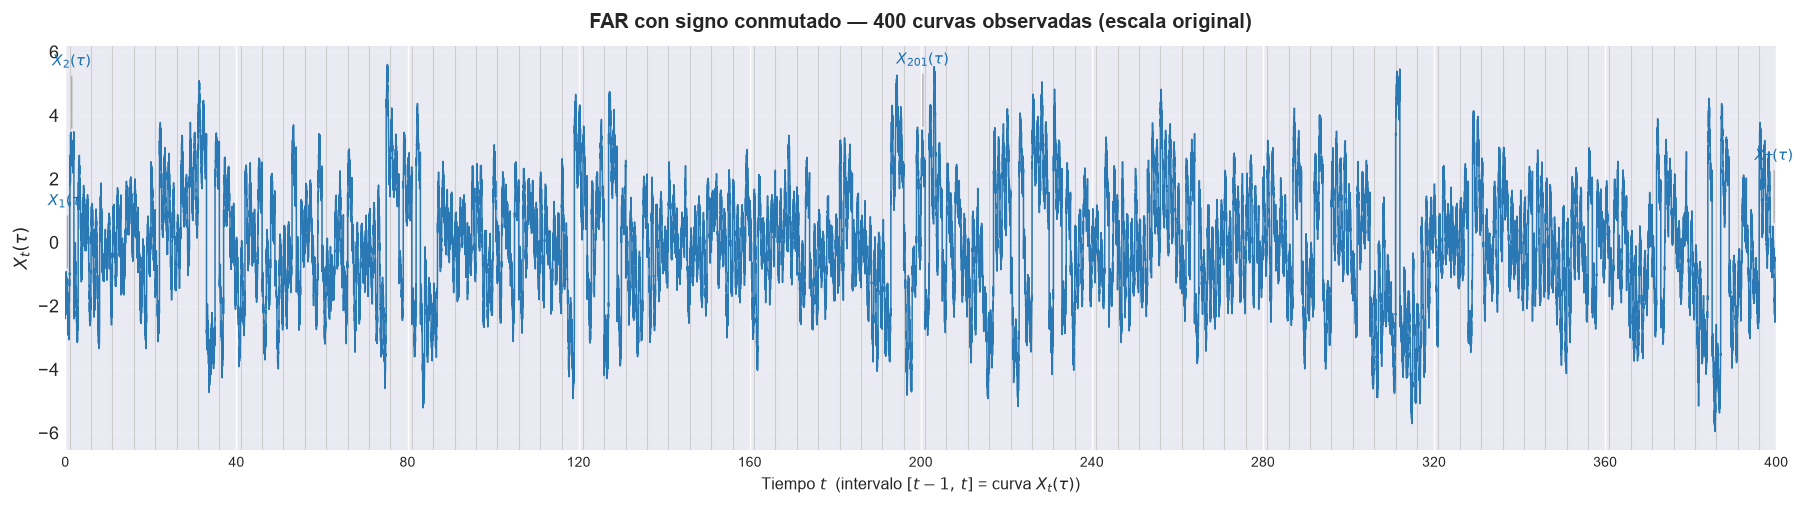

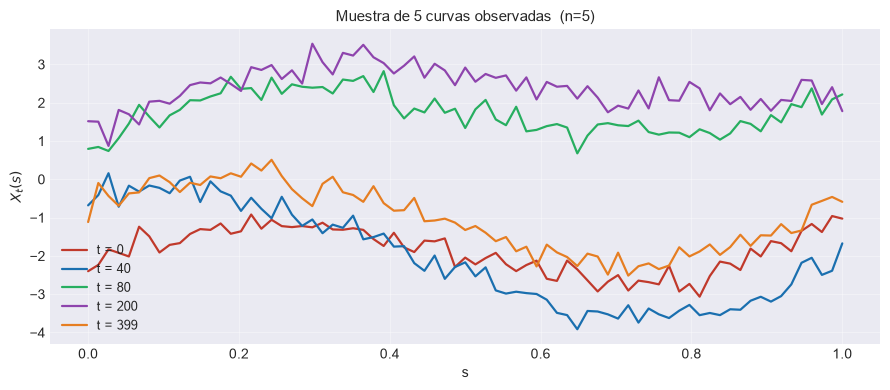

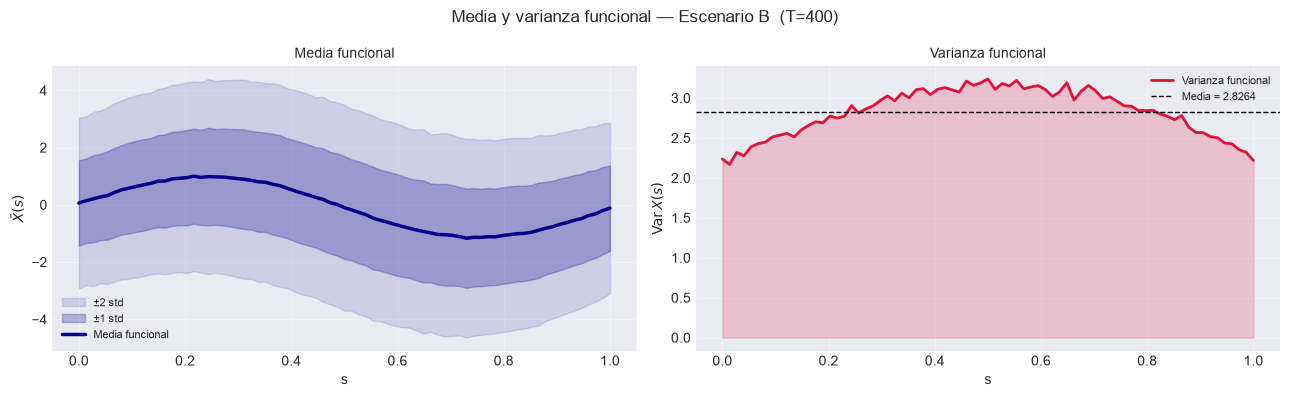

In [ ]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR con signo conmutado — {T} curvas observadas (escala original)",
    save_path=str(PATHS["out_report"] / "01_fts_empirica_raw.png"))
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas",
    save_path=str(PATHS["out_report"] / "02_muestra_empirica_raw.png"))
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — Escenario B",
    save_path=str(PATHS["out_report"] / "03_media_varianza_raw.png"))
plt.show()

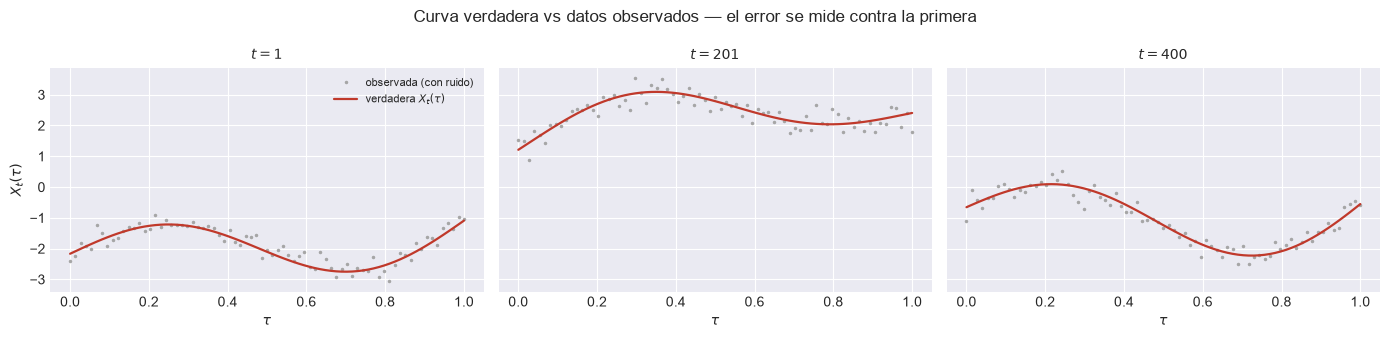

In [ ]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "04_curva_vs_datos.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.6 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [ ]:
_p = guardar_curvas(PATHS, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} → {ruta.name}")

[functional] curvas       → X_curves.npy
[functional] grilla       → domain_grid.npy
[functional] curvas_true  → X_curves_true.npy


### 2.7 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [ ]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 280]      → (280, 75)
prueba        : t ∈ [281, 400]  → (120, 75)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,87.8096%,0.562745,0.843418,0.341179
1,3,2,89.3467%,0.526881,0.750878,0.306500
2,4,2,97.0506%,0.278494,0.367271,0.087263
3,5,2,97.5209%,0.255553,0.326963,0.075457
4,6,2,97.7026%,0.245916,0.309517,0.071970
5,7,2,97.7843%,0.241512,0.311033,0.071466
6,8,2,97.8375%,0.238603,0.309017,0.071849
7,9,2,97.8841%,0.235989,0.310969,0.072446
8,10,2,97.9194%,0.233983,0.304813,0.073446
9,11,2,97.9532%,0.232104,0.304771,0.074530



GCV mínimo → n_basis=4, order=3  (var retenida 97.6964%)


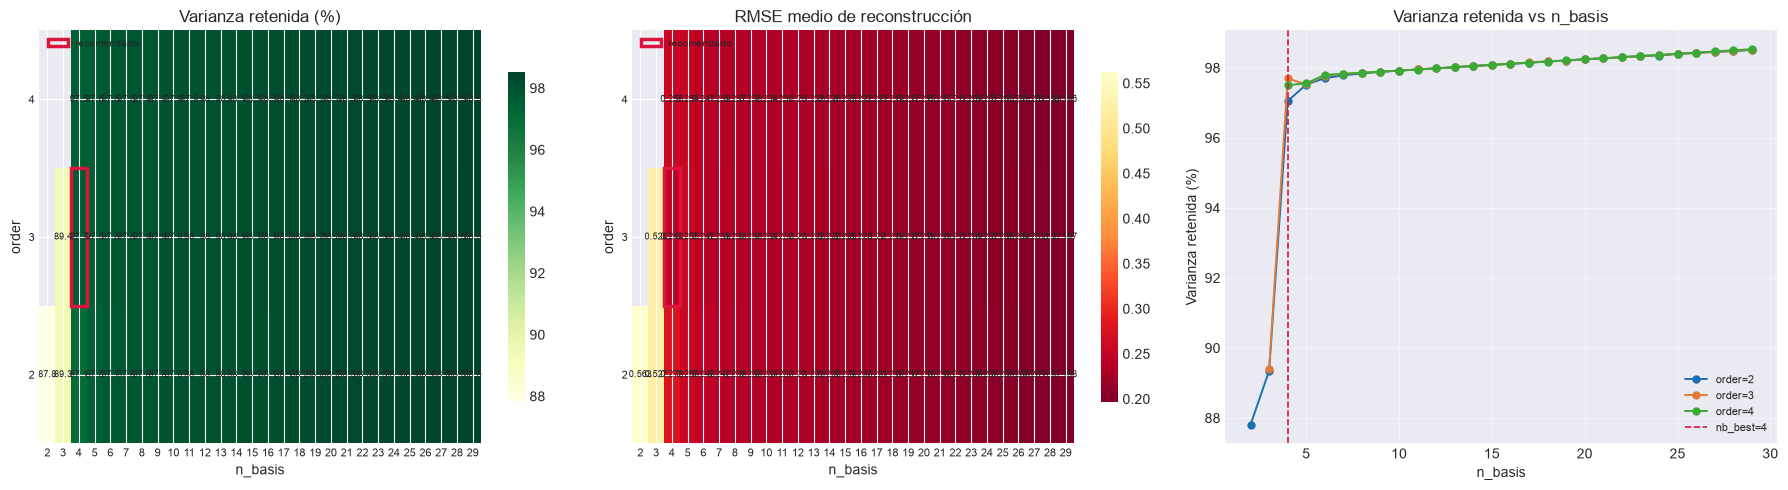

In [ ]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best,
                     save_path=str(PATHS["out_report"] / "05_seleccion_basis.png"))
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=4, order=3
Sugerido GCV : n_basis=4, order=3   (coinciden)
THETA (400, 4)  (train=280, test=120)


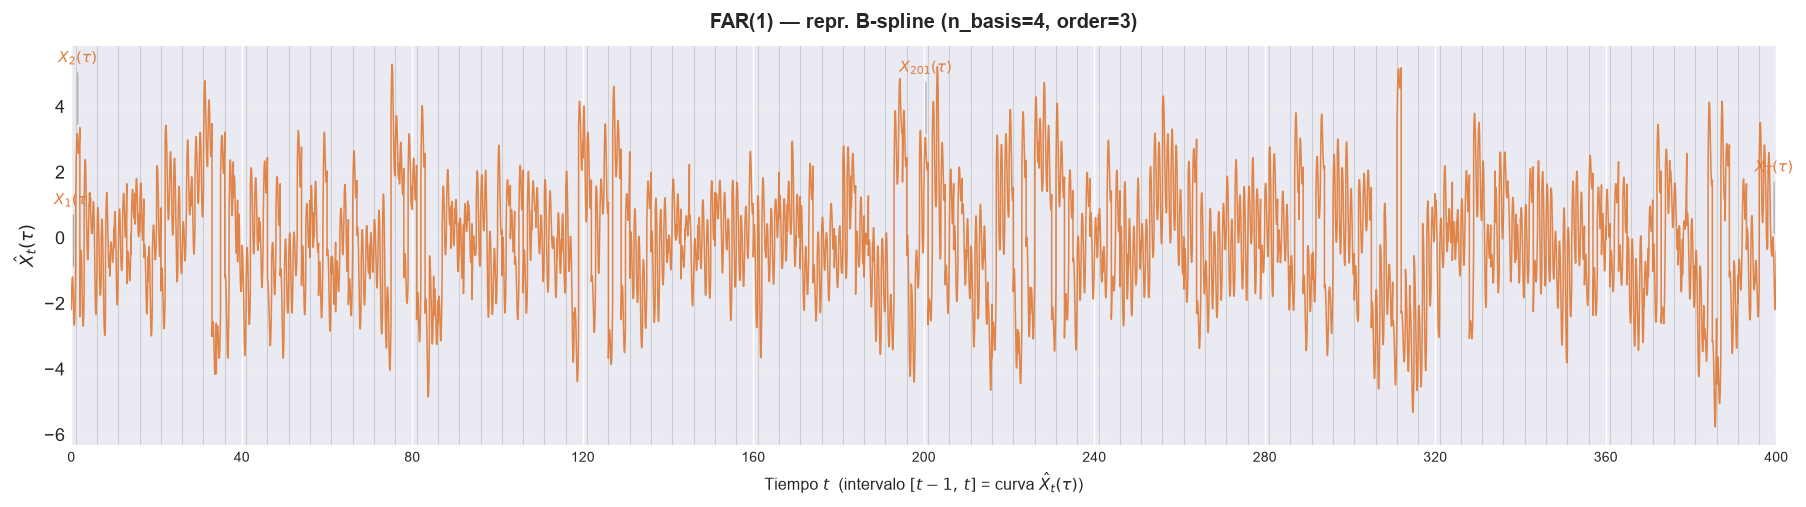

[functional] functional_representation.pkl + theta.csv + fr_config.json


In [ ]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})",
    save_path=str(PATHS["out_report"] / "06_fts_funcional_bspline.png"))
plt.show()

guardar_representacion(PATHS, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print("[functional] functional_representation.pkl + theta.csv + fr_config.json")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [ ]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 4
  K                                  = 4
  n_ajuste                           = 280
  cond_W                             = 9.439e+00
  err_ortonormalidad_L2              = 2.442e-15
  err_ortonormalidad_gram            = 2.220e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 5.389e-16
  err_media_scores_rel               = 1.999e-15
  err_var_scores_vs_lambda           = 6.050e-16
  err_var_scores_vs_lambda_rel       = 1.833e-13
  err_correlacion_lag0               = 3.783e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,2.3922e+00,91.7332%,91.7332%,+0.020
1,2,1.8788e-01,7.2044%,98.9376%,+0.123
2,3,2.4404e-02,0.9358%,99.8734%,-0.034
3,4,3.3009e-03,0.1266%,100.0000%,-0.017



K disponibles: 4   ·   sugerencia (var ≥ 95%): M = 2


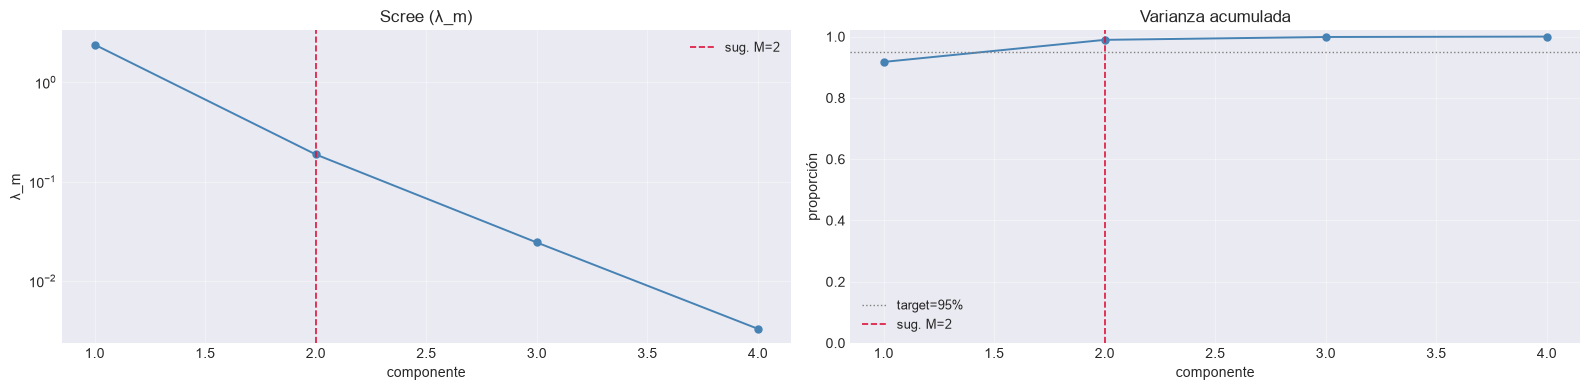

In [ ]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET,
                save_path=str(PATHS["out_report"] / "07_fpca_scree.png"))
plt.show()

### 3.4 `[CONFIG]` Componentes FPCA retenidas

In [ ]:
# M_FPCA se declara arriba, en la celda [BARRIDO] de §1.1, porque forma parte
# del EXPERIMENT_ID y las rutas se arman antes de llegar aquí. Esta celda sólo
# lo consume y lo contrasta con la regla del 95 % (M_SUGERIDO, de §3.3).
assert 1 <= M_FPCA <= fpca.evals.size, f"M_FPCA fuera de [1, {fpca.evals.size}]."

print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
print(f"M_FPCA de esta corrida : {M_FPCA}"
      + ("   (coincide con la regla)" if M_FPCA == M_SUGERIDO
         else "   ← DIFIERE de la regla: es un punto del barrido"))
fpca.set_M(int(M_FPCA))
M_fpca = fpca.M

Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
SCORES_train = SCORES[idx_train]
SCORES_test  = SCORES[idx_test]

print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
print(f"[train] max|media ξ| = {np.abs(SCORES_train.mean(0)).max():.2e}   (≈ 0)")
print(f"[test]  max|media ξ| = {np.abs(SCORES_test.mean(0)).max():.3f}")
print(f"[test]  var ξ / λ    = "
      f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

M(95 %) según la regla : 2   (K disponible = 4)
M_FPCA de esta corrida : 1   ← DIFIERE de la regla: es un punto del barrido
M = 1   var. explicada = 91.7332%
[train] max|media ξ| = 5.39e-16   (≈ 0)
[test]  max|media ξ| = 0.317
[test]  var ξ / λ    = [1.191]


### 3.5 ¿Observa el modelo la dirección de conmutación?

Es la pregunta propia de este escenario y no tiene análogo en las corridas
11–16. La conmutación la gobierna $z_{t-1} = \langle X_{t-1}-\mu, e\rangle$, y
el modelo sólo ve los $M$ scores retenidos: si $e$ no está en el espacio que
generan las $M$ autofunciones, **la covariable que decide el régimen no entra
en el modelo** y ninguna flexibilidad puede recuperarla.

Con la dirección por defecto, $e \propto \sin 2\pi\tau$ carga casi toda su masa
sobre la **segunda** componente. La consecuencia es una predicción falsable
antes de correr nada:

| $M$ | ¿Ve la conmutación? | Predicción |
|---|---|---|
| 1 | no | falla como el FAR(1): $R^2 \approx 0$ |
| $\ge 2$ | sí | recupera parte de la brecha del oráculo |

`fraccion_e_explicada` es $\sum_{k\le M}\langle e,\phi_k\rangle^2$, la fracción
de $e$ que vive en el espacio retenido: es la cifra que decide de qué lado de
la tabla cae este punto del barrido. Se persiste para que `_04 §11` la cruce
con el MISE de cada $M$.


In [ ]:
# Autofunciones retenidas sobre la grilla y las descartadas, para poder decir
# DÓNDE está la dirección de conmutación y no sólo si está.
_e     = salida.internos["direccion_estado"]         # (G,) norma 1 en L2
_w     = salida.internos["pesos_cuadratura"]
_PHI   = Psi_grid                                     # (G, M) las retenidas

cargas = np.array([float(np.sum(_w * _e * _PHI[:, k])) for k in range(_PHI.shape[1])])
frac_e = float(np.sum(cargas ** 2))                   # <= 1 por Bessel

alineacion = pd.DataFrame({
    "fpc":            np.arange(1, _PHI.shape[1] + 1),
    "carga_e":        cargas,                          # <e, phi_k>
    "carga_e2":       cargas ** 2,                     # participación en la dirección
    "var_ratio":      fpca.var_ratio[:_PHI.shape[1]],
    "retenida":       1,
})
alineacion.to_csv(PATHS["out_report"] / "10_alineacion_conmutacion.csv", index=False)

print("Carga de la dirección de conmutación sobre cada FPC retenida:")
print(alineacion.to_string(index=False,
      formatters={"carga_e": "{:+.4f}".format, "carga_e2": "{:.4f}".format,
                  "var_ratio": "{:.2%}".format}))
print(f"\nfraccion_e_explicada (M={M_fpca}) = {frac_e:.4f}")

if frac_e < 0.25:
    print("\n[AVISO] Con este M el modelo NO observa la dirección que gobierna la\n"
          "        conmutación: se espera que falle como el FAR(1). Es el punto\n"
          "        BAJO del barrido y su fracaso es un resultado, no un error.")
else:
    print("\n[OK] La dirección de conmutación está en el espacio retenido: este\n"
          "     punto del barrido SÍ puede recuperar la brecha del oráculo.")

# La comparación entre M sólo tiene sentido si la dirección es la misma en
# todos los puntos, y lo es por construcción: no depende de M ni del ajuste.
FRAC_E_EXPLICADA = frac_e


Carga de la dirección de conmutación sobre cada FPC retenida:
 fpc carga_e carga_e2 var_ratio  retenida
   1 +0.0019   0.0000    91.73%         1

fraccion_e_explicada (M=1) = 0.0000

[AVISO] Con este M el modelo NO observa la dirección que gobierna la
        conmutación: se espera que falle como el FAR(1). Es el punto
        BAJO del barrido y su fracaso es un resultado, no un error.


## 4. Datasets AR($p$) sobre los scores

### 4.1 Estandarización

El estandarizador se ajusta **sólo con train** y registra `n_ajuste` para que
esa disciplina sea auditable desde el artefacto y no una promesa del notebook.

[holdout] ajustado con 280 filas = T0 (train[1:280]) → ok=True

SCORES_STD (400, 1)
  [train] max|media| = 2.54e-17  (≈0)
  [train] max|std-1| = 0.00e+00  (≈0)
  [test]  media = [0.206]
  [test]  std   = [1.089]

[functional] artefactos FPCA · cond_W = 9.439e+00


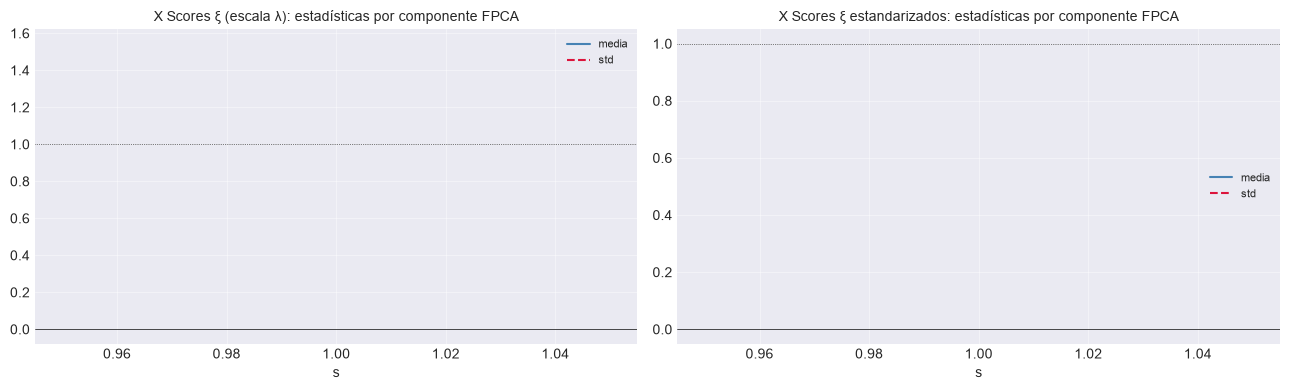

In [ ]:
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

_chk = scores_standardizer.verificar_ajuste(T0)
print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
      f"({_chk['etiqueta_ajuste']}) → ok={_chk['ajuste_ok']}")

SCORES_STD       = scores_standardizer.transform(SCORES)
SCORES_STD_train = SCORES_STD[idx_train]
SCORES_STD_test  = SCORES_STD[idx_test]

print(f"\nSCORES_STD {SCORES_STD.shape}")
print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (≈0)")
print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (≈0)")
print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

guardar_estandarizador(PATHS, scores_standardizer)
_res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                    meta_extra={"T0": int(T0)})
print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

plot_diagnostico_estandarizacion(
    SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
plt.show()

### 4.2 Diagnóstico de rezagos (sólo train)

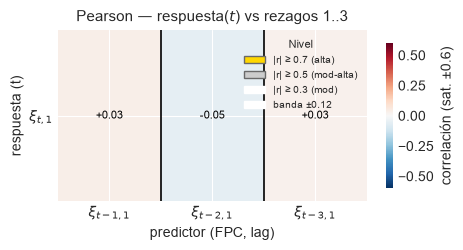

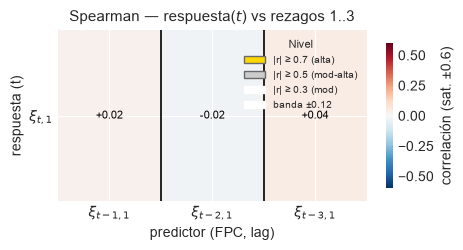

In [ ]:
N_LAGS_MAX = 3
T_theta, K_total = SCORES_STD_train.shape

def _spearman(Y, Xm):
    """Spearman columna a columna vía rangos (pandas, sin scipy)."""
    Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
    Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
corr_s = np.zeros_like(corr_p)
col_labels = []
y_block = SCORES_STD_train[N_LAGS_MAX:, :]

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
    sp = _spearman(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_s[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band = 1.96 / np.sqrt(len(y_block))

for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
    plot_rezagos_heatmap(
        M_corr, col_labels, row_labels,
        title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}",
        n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
        save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
    plt.show()

### 4.3 `[CONFIG]` Orden AR y construcción de los datasets

Los rezagos del primer origen de prueba vienen del final del bloque de
entrenamiento: son observaciones pasadas disponibles en cada origen, de modo
que su uso es el condicionamiento de la predicción a $h=1$, no fuga.

In [ ]:
N_LAGS        = 1
COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

n_components = len(COMPONENT_IDX)
n_train_eff  = T0 - N_LAGS
n_test_eff   = T - T0

assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
             for lag in range(1, N_LAGS + 1)
             for j in range(n_components)]

print(f"componentes : {n_components} → índices {COMPONENT_IDX}")
print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
print(f"cov_names   : {cov_names}")

componentes : 1 → índices [0]
N_LAGS      : 1   ·   p = 1 covariables
n_train_eff : 279   n_test_eff : 120
cov_names   : ['fpc_1_lag1']


In [ ]:
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

def _dataset_bloque(k, t_ini, t_fin):
    """Respuesta en t ∈ [t_ini, t_fin) y predictores en t-1 … t-N_LAGS."""
    t_idx  = np.arange(t_ini, t_fin)
    X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
    return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                        columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
    "ajuste_en": "train",
}
guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
for k in range(n_components):
    print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (279, 2) · test (120, 2)


## 5. `[CONFIG]` Hiperparámetros y configuración MCMC

Esto es el **contrato con MATLAB**: `psbp_fd_iteracion.m` lee estos valores del
JSON y no los tiene escritos a mano, incluida `seed_base`.

Ojo con la doble acepción de `M`: aquí, dentro de `mcmc_config`, es el tamaño
de la grilla de localización $G^*$ del stick-breaking, **no** el número de
componentes FPCA. `N` es el truncamiento del número de átomos.

In [ ]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 35, "M": 35}
N_CHAINS    = 3

print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS} cadenas por componente "
      f"→ {N_CHAINS * n_components} jobs en MATLAB")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) × {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

MCMC_CONFIG : {'nsim': 2000, 'burn': 500, 'N': 35, 'M': 35}
N_CHAINS    : 3 cadenas por componente → 3 jobs en MATLAB
Draws posteriores por score: (2000 - 500) × 3 = 4500


In [ ]:
# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors por tipo de covariable: (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0, 0.0, 1.0),   # E[pi] = 0.90 — el propio rezago 1
    "cross_lag": (1.0, 1.0, 0.0, 1.0),   # E[pi] = 0.50 — los cruzados
}

def _clasificar(nombre, k_modelo):
    return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
            else "cross_lag")

HYPERPARAMS_LIST = []
for k in range(n_components):
    tipos = [_clasificar(nm, k) for nm in cov_names]
    vals  = np.array([HP_BY_TYPE[t] for t in tipos], dtype=float)   # (p, 4)
    HYPERPARAMS_LIST.append({**HP_GLOBAL,
        "apij": vals[:, 0], "bpij": vals[:, 1],
        "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
    for j, nm in enumerate(cov_names):
        a, b = hp["apij"][j], hp["bpij"][j]
        marca = "  ◄" if _clasificar(nm, k) == "own_lag1" else ""
        print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
              f"{a/(a+b):>7.3f}{marca}")


Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  ◄


In [ ]:
hp_artifact = {
    "global":       HP_GLOBAL,
    "by_type":      HP_BY_TYPE,
    "mcmc_config":  MCMC_CONFIG,
    "n_iter":       N_CHAINS,
    "seed_scheme":  "seed_base + chain*9973 + k*31",
    # Cadena "B", no entero. El .m no lo lee ---arma el EXPERIMENT_ID con su
    # propio ESCENARIO_ID y un %s--- pero el artefacto debe registrar el
    # identificador tal cual es, o deja de emparejar con el nombre del directorio.
    "escenario_id": ESCENARIO_ID,
    "replica_id":   int(REPLICA_ID),
    "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
    "scores_scale": "standardized_zscore_ddof0",
    "partition": {
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                        for k in range(n_components)],
        "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                        for k in range(n_components)],
    },
    "hyperparams_list": [
        {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
         "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                         for key, v in HYPERPARAMS_LIST[k].items()}}
        for k in range(n_components)
    ],
}
guardar_hiperparametros(PATHS, hp_artifact)
print(f"✓ hyperparameters.json → {PATHS['out_artefact']}")

✓ hyperparameters.json → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_B_r01_m01


## 6. Configuración de evaluación, líneas base y verificación del contrato

`objetivo_evaluacion` y `modo_residuo` se declaran aquí porque cambian el
significado de toda la evaluación y no deben quedar como una decisión implícita
del notebook `_04`.

In [ ]:
eval_config = {
    "scheme":      "holdout_temporal",
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "horizons":    [1],
    "n_lags":      int(N_LAGS),
    "scores_scale": "standardized_zscore_ddof0",
    # Contra QUÉ se mide el error y con qué banda. Declarado explícitamente:
    #   curva_verdadera + modo_residuo "ninguno" ⇒ la banda cubre la curva
    #   PROYECTADA sobre las M autofunciones y se contrasta con X_t(tau). Lo
    #   que queda fuera es truncamiento FPCA puro, sin el ruido de medición.
    "objetivo_evaluacion": "curva_verdadera",
    "modo_residuo":        "ninguno",
    "nivel_credibilidad":  0.95,
    "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
    "metrics_scores": ["RMSE", "R2", "razon_dispersion"],
    "metrics_curvas": ["MISE", "RMSE_funcional"],
    "metrics_dist":   ["CRPS", "energy_score", "cobertura_95", "PIT"],
    # ── Estratificación por el estado VERDADERO del generador ──────────────
    # A diferencia de la corrida 16, el estrato NO coincide con la partición
    # train/test: la ambigüedad depende del estado rezagado y está repartida a
    # lo largo de toda la serie. La cobertura condicional mide por tanto algo
    # distinto de la comparación train/test.
    "estratificacion": {
        "variable":  "ambiguo",
        "fuente":    "reports/<EXPERIMENT_ID>/10_estado_signo.csv",
        "metodo":    "estado discreto del generador (no se cuantiliza)",
        "n_estratos": 2,
        "etiquetas": ["determinista", "ambiguo"],
        "nota": ("`bimodal` = ambiguo Y con estado grande es el subconjunto que "
                 "sostiene el argumento distribucional: la separación entre modas "
                 "es 2||Psi Y_{t-1}||, proporcional al estado."),
    },
    # ── Referencias ORACLE del generador ───────────────────────────────────
    # Son las cifras contra las que _04 §9.1 contrasta la predictiva del modelo.
    # La corrida 13 no las tenía y por eso no pudo decidir si su coeficiente de
    # Sarle bajo era un hallazgo sobre el modelo o un defecto del generador.
    "forma_predictiva": {
        "r2_lineal_fuera_de_muestra":  DIAG["r2_lineal_fuera_de_muestra"],
        "r2_oraculo_fuera_de_muestra": DIAG["r2_oraculo_fuera_de_muestra"],
        "brecha_oraculo_lineal":       DIAG["brecha_oraculo_lineal"],
        "sarle_oraculo_bimodales":     DIAG["sarle_oraculo_bimodales"],
        "sarle_oraculo_ambiguos":      DIAG["sarle_oraculo_ambiguos"],
        "sarle_oraculo_deterministas": DIAG["sarle_oraculo_deterministas"],
        "sarle_referencia_uniforme":   DIAG["sarle_referencia_uniforme"],
        "sarle_referencia_gaussiana":  DIAG["sarle_referencia_gaussiana"],
        "separacion_modas_en_sd_innovacion": DIAG["separacion_modas_en_sd_innovacion"],
        "fraccion_origenes_ambiguos":  DIAG["fraccion_origenes_ambiguos"],
        "fraccion_origenes_bimodales": DIAG["fraccion_origenes_bimodales"],
    },
    # Cuánto de la dirección de conmutación ve el modelo con ESTE M (§3.5).
    "fraccion_e_explicada": float(FRAC_E_EXPLICADA),
}
guardar_config_evaluacion(PATHS, eval_config)
print("[out_artefact] eval_config.json")
for k, v in eval_config.items():
    print(f"  {k:22s}: {v}")

[out_artefact] eval_config.json
  scheme                : holdout_temporal
  T                     : 400
  T0                    : 280
  prop_train            : 0.7
  horizons              : [1]
  n_lags                : 1
  scores_scale          : standardized_zscore_ddof0
  objetivo_evaluacion   : curva_verdadera
  modo_residuo          : ninguno
  nivel_credibilidad    : 0.95
  ventana_movil         : {'w': [10, 20, 40], 'paso': 1, 'solapadas': True}
  metrics_scores        : ['RMSE', 'R2', 'razon_dispersion']
  metrics_curvas        : ['MISE', 'RMSE_funcional']
  metrics_dist          : ['CRPS', 'energy_score', 'cobertura_95', 'PIT']
  estratificacion       : {'variable': 'ambiguo', 'fuente': 'reports/<EXPERIMENT_ID>/10_estado_signo.csv', 'metodo': 'estado discreto del generador (no se cuantiliza)', 'n_estratos': 2, 'etiquetas': ['determinista', 'ambiguo'], 'nota': '`bimodal` = ambiguo Y con estado grande es el subconjunto que sostiene el argumento distribucional: la separación ent

In [ ]:
# Líneas base a h=1: el piso que el PSBP-FD debe superar.
baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                               fpca=fpca, X_obs=X_true, tau=grilla, h=1)
baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
display(baselines_df.style.format("{:.4f}", na_rep="—")
        .set_caption("Líneas base — bloque de prueba, h=1, contra la curva VERDADERA"))

,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,120.0000,1.1080,1.1080,-0.0357,3.1845,1.7845
persistencia_lag1,120.0000,1.4857,1.4857,-0.8622,5.5203,2.3495


In [ ]:
informe = verificar_contrato(PATHS)
print(f"contrato_ok = {informe['contrato_ok']}   "
      f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
      f"n_components={informe['n_components']})")
print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas (T0={informe['T0']})")
print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
if not informe["contrato_ok"]:
    print("\nPROBLEMAS:")
    for p in informe.get("problemas", []):
        print(f"  - {p}")

print(f"\n{'='*66}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"EXPERIMENT_ID = {EXPERIMENT_ID}\n{'='*66}")

contrato_ok = True   (M=1, K=4, T0=280, n_components=1)
estandarizador ajustado con 280 filas (T0=280)
verificación FPCA: todo_ok = True

Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
EXPERIMENT_ID = escenario_B_r01_m01
